# Experiment Module Assignment 

**Student Name:** Zejun Li

**U-M Unique Name:** zejunli

## Part 1: Research Question and Hypothesis

### Research Question

This experiment tests whether making assignment reminders more actionable in a Canvas-like course portal improves student behavior. Specifically: does a structured reminder that includes the assignment name, a direct link, and an estimated completion time (e.g., “Discussion Post due in 18 hours — ~20 min — [link]”) lead to more on-time or early submissions than a generic reminder (e.g., “You have an assignment due soon”)?

The treatment group receives the structured reminder, while the control group receives the default generic version. I measure two outcomes:

- On-time submission rate (binary): whether the assignment is submitted before the deadline, capturing whether the reminder successfully prompts action.
- Days before deadline (continuous): how early the assignment is submitted, capturing reductions in procrastination rather than just last-minute compliance.

### Hypothesis

I hypothesize that students in the treatment condition will have significantly higher on-time submission rates and will submit assignments earlier than students in the control condition. The proposed mechanism is friction reduction and salience: as Salganik emphasizes, treatments work through specific causal mechanisms, and the mechanism here is that a vague reminder fails to reduce the cognitive friction of acting. When students have to open Canvas, locate the assignment, and estimate the time needed, many defer action. A structured reminder removes these barriers by surfacing the assignment name, a time estimate, and direct link, reducing the effort cost of starting. This mechanism of lowering action friction to translate intention into behavior is consistent with research on behavioral nudges in digital environments.

## Part 2: Experimental Design

### Randomization Unit

I randomize at the user (student) level, so each student stays in either treatment or control for the entire semester. The main tradeoff is vs. session-level randomization: while session-level would allow within-person comparisons, it risks carryover effects if students notice inconsistent reminders. User-level randomization avoids contamination and better reflects how this would actually be rolled out.

### Design Type

This is a between-subjects design, where each student sees only one version of the reminder. A within-subjects design wouldn’t work well for this experiment because exposure to the structured reminder could change how students respond to future reminders (e.g., priming or habit formation), making the treatment effect harder to isolate.

### Sample and Eligibility

The target population is undergraduate students who use Canvas for assignment submissions. I exclude:

1. Students with no upcoming assignments
2. Students who have disabled Canvas notifications

The experiment sample size is 200 students (100 per condition).

### Treatment Delivery

* **Control:** Students receive the default reminder: “You have an assignment due soon,” via push notification and email.
* **Treatment:** Students receive a structured reminder 24 hours before the deadline:
  *“[Course Name]: [Assignment Name] due in 24 hours — ~[X] min — [Link →]”*
  The time estimate comes from the instructor, and delivery channels are identical across conditions to isolate the effect of the message itself.

### Measurement

**Outcome 1: On-time submission rate**
Binary (1 = submitted before deadline, 0 = late or missing), pulled from Canvas logs.
*Validity threat:* deadline extensions could misclassify submissions; I would exclude assignments with approved extensions.

**Outcome 2: Days before deadline**
Continuous: ((\text{deadline} - \text{submission}) / 86400), in days. Negative values indicate lateness.
*Validity threat:* extreme early submissions could skew the mean, so I would also report the median and check for outliers.


## Part 3: Simulate and Analyze Data

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)

# Set random seed for reproducibility
np.random.seed(42)

In [ ]:
# Simulate dataset: 200 participants, 100 per condition
n = 100 

# --- Control group ---
# On-time submission: ~65% submit on time (realistic baseline for generic reminders)
control_ontime = np.random.binomial(1, 0.65, n)

# Days before deadline: control group submits closer to deadline on average
# Mean ~0.5 days before, SD ~1.2; can be negative (late)
control_days = np.random.normal(0.5, 1.2, n)

# --- Treatment group ---
# On-time submission: ~80% submit on time (structured reminder reduces friction)
treatment_ontime = np.random.binomial(1, 0.80, n)

# Days before deadline: treatment group submits earlier
# Mean ~1.2 days before, SD ~1.2
treatment_days = np.random.normal(1.2, 1.2, n)

# Combine into a single dataframe
df = pd.DataFrame({
    'participant_id': range(1, 2 * n + 1),
    'condition': ['control'] * n + ['treatment'] * n,
    'on_time': np.concatenate([control_ontime, treatment_ontime]),
    'days_before_deadline': np.concatenate([control_days, treatment_days])
})

print(f"Dataset shape: {df.shape}")
print(df.head(10))

Dataset shape: (200, 4)
   participant_id condition  on_time  days_before_deadline
0               1   control        1              0.604456
1               2   control        0              0.141191
2               3   control        0              0.610113
3               4   control        1             -1.885083
4               5   control        1              0.236394
5               6   control        1              0.928535
6               7   control        1              2.273473
7               8   control        0             -0.121924
8               9   control        1             -0.470192
9              10   control        0             -0.102108


In [3]:
# Summary statistics by condition
print(df.groupby('condition')[['on_time', 'days_before_deadline']].describe().round(3))

          on_time                                       days_before_deadline  \
            count  mean    std  min  25%  50%  75%  max                count   
condition                                                                      
control     100.0  0.68  0.469  0.0  0.0  1.0  1.0  1.0                100.0   
treatment   100.0  0.79  0.409  0.0  1.0  1.0  1.0  1.0                100.0   

                                                            
            mean    std    min    25%    50%    75%    max  
condition                                                   
control    0.499  1.096 -1.885 -0.346  0.593  1.080  3.456  
treatment  1.214  1.080 -2.690  0.488  1.219  1.954  3.760  


### Visualizations

C:\Users\tingt\AppData\Local\Temp\ipykernel_1832\82630936.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


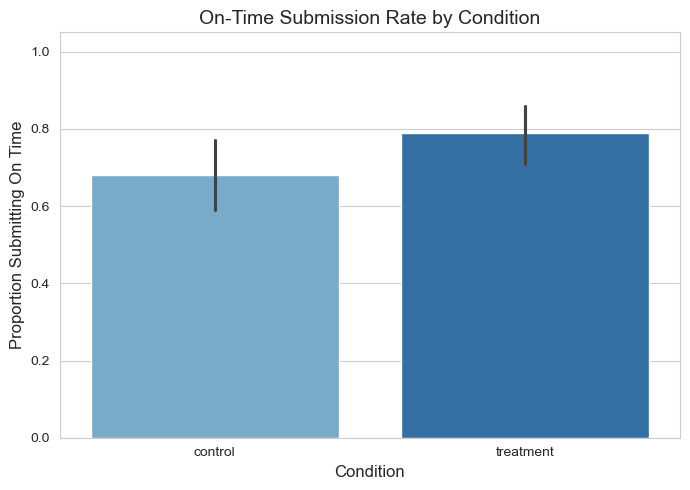

In [ ]:
# Visualization 1: On-time submission rate by condition 
ontime_means = df.groupby('condition')['on_time'].mean().reset_index()
ontime_means.columns = ['condition', 'on_time_rate']

plt.figure(figsize=(7, 5))
sns.barplot(
    data=df,
    x='condition',
    y='on_time',
    errorbar=('ci', 95),
    palette=['#6baed6', '#2171b5']
)
plt.title('On-Time Submission Rate by Condition', fontsize=14)
plt.xlabel('Condition', fontsize=12)
plt.ylabel('Proportion Submitting On Time', fontsize=12)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

C:\Users\tingt\AppData\Local\Temp\ipykernel_1832\2575596111.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


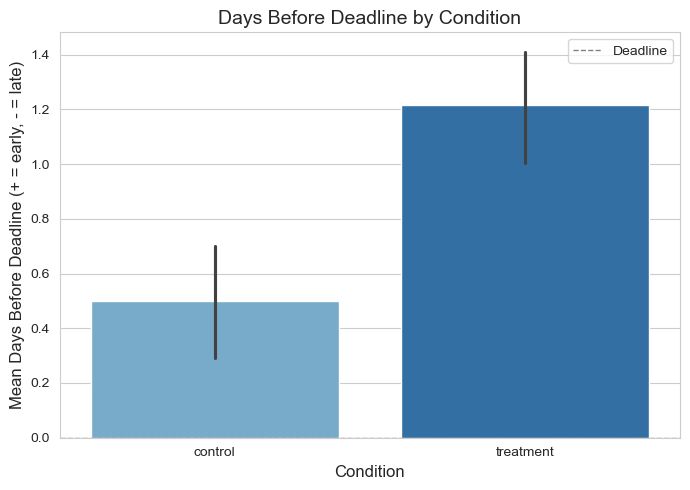

In [ ]:
# Visualization 2: Days before deadline by condition
plt.figure(figsize=(7, 5))
sns.barplot(
    data=df,
    x='condition',
    y='days_before_deadline',
    errorbar=('ci', 95),
    palette=['#6baed6', '#2171b5']
)
plt.axhline(0, color='gray', linestyle='--', linewidth=1, label='Deadline')
plt.title('Days Before Deadline by Condition', fontsize=14)
plt.xlabel('Condition', fontsize=12)
plt.ylabel('Mean Days Before Deadline (+ = early, - = late)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\tingt\AppData\Local\Temp\ipykernel_1832\2691453326.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


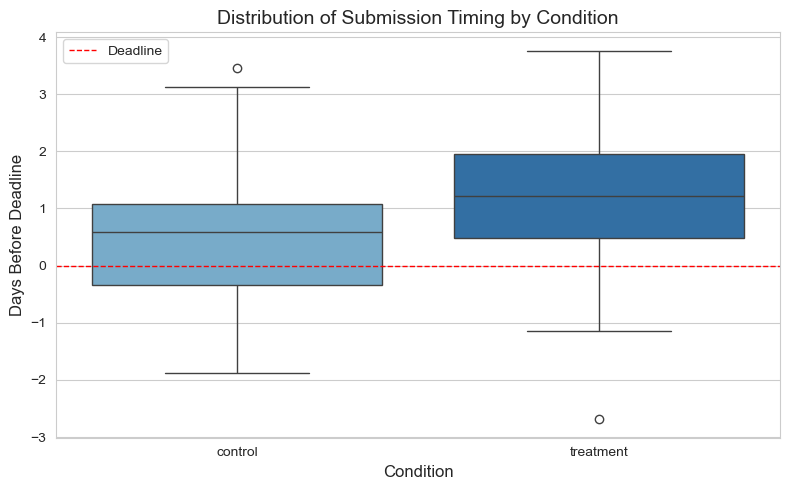

In [ ]:
# Visualization 3: Distribution of days before deadline 
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x='condition',
    y='days_before_deadline',
    palette=['#6baed6', '#2171b5']
)
plt.axhline(0, color='red', linestyle='--', linewidth=1, label='Deadline')
plt.title('Distribution of Submission Timing by Condition', fontsize=14)
plt.xlabel('Condition', fontsize=12)
plt.ylabel('Days Before Deadline', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

### Statistical Tests

In [7]:
# Split data by condition
control_group = df[df['condition'] == 'control']
treatment_group = df[df['condition'] == 'treatment']

# --- T-test 1: On-time submission rate ---
t1, p1 = ttest_ind(treatment_group['on_time'], control_group['on_time'])

# Cohen's d = (mean1 - mean2) / pooled SD
mean_diff1 = treatment_group['on_time'].mean() - control_group['on_time'].mean()
pooled_sd1 = np.sqrt(
    (treatment_group['on_time'].std()**2 + control_group['on_time'].std()**2) / 2
)
cohens_d1 = mean_diff1 / pooled_sd1

print("=== Outcome 1: On-Time Submission Rate ===")
print(f"  Control mean:   {control_group['on_time'].mean():.3f}")
print(f"  Treatment mean: {treatment_group['on_time'].mean():.3f}")
print(f"  t-statistic:    {t1:.3f}")
print(f"  p-value:        {p1:.3f}")
print(f"  Cohen's d:      {cohens_d1:.3f}")
print()

=== Outcome 1: On-Time Submission Rate ===
  Control mean:   0.680
  Treatment mean: 0.790
  t-statistic:    1.767
  p-value:        0.079
  Cohen's d:      0.250



In [8]:
# T-test 2: Days before deadline
t2, p2 = ttest_ind(treatment_group['days_before_deadline'], control_group['days_before_deadline'])

mean_diff2 = treatment_group['days_before_deadline'].mean() - control_group['days_before_deadline'].mean()
pooled_sd2 = np.sqrt(
    (treatment_group['days_before_deadline'].std()**2 + control_group['days_before_deadline'].std()**2) / 2
)
cohens_d2 = mean_diff2 / pooled_sd2

print("=== Outcome 2: Days Before Deadline ===")
print(f"  Control mean:   {control_group['days_before_deadline'].mean():.3f} days")
print(f"  Treatment mean: {treatment_group['days_before_deadline'].mean():.3f} days")
print(f"  t-statistic:    {t2:.3f}")
print(f"  p-value:        {p2:.3f}")
print(f"  Cohen's d:      {cohens_d2:.3f}")

=== Outcome 2: Days Before Deadline ===
  Control mean:   0.499 days
  Treatment mean: 1.214 days
  t-statistic:    4.654
  p-value:        0.000
  Cohen's d:      0.658


### Results

**On-Time Submission Rate:**
An independent samples t-test revealed that students in the structured reminder condition (M = 0.79, SD = 0.41) had higher on-time submission rates than students in the generic reminder condition (M = 0.68, SD = 0.47), t(198) = 1.77, p = .079, d = 0.25. This result is not statistically significant at the α = .05 level.

**Days Before Deadline:**
An independent samples t-test indicated that students in the structured reminder condition (M = 1.21, SD = 1.08) submitted assignments earlier than students in the generic reminder condition (M = 0.50, SD = 1.10), t(198) = 4.65, p < .001, d = 0.66. This result is statistically significant, with a medium effect size.

**Interpretation: Statistical vs. Practical Significance**

These results highlight the difference between statistical significance and practical importance. The increase in on-time submissions (~11 percentage points) is not statistically significant in this sample, but could still be meaningful at scale in a real university setting. In contrast, the earlier submission timing is statistically significant, but a ~0.7 day shift may be less impactful in practice, since the key outcome for instructors is whether assignments are submitted on time rather than how early they are.


## Part 4: Ethical Review

### Informed Consent and IRB

This study would require IRB review since it involves students and could affect academically meaningful behavior. Unlike Kramer et al. (2014), which manipulated users’ feeds without disclosure, this experiment could use a deferred consent model: students are told at the start of the semester that notification formats are being tested, without revealing condition assignment, and are fully debriefed afterward. This is more transparent than the Kramer study, though there’s still a valid concern that, given the stakes (grades), full upfront consent may be more appropriate.

### Potential Harms

The main risk is to the control group. If the structured reminder is beneficial, these students miss out on something that could improve their performance, a concern raised by Delia Baldassarri and Omar Abascal around withholding beneficial treatments. That said, the risk is limited: the experiment only lasts one semester, and control students still receive standard reminders. For the treatment group, harms are minimal but possible, as more detailed reminders could increase stress by making deadlines feel more immediate.

### External Validity

These results would generalize best to undergraduates at universities using Canvas or similar platforms. There are limits: different academic cultures, course structures (e.g., weekly vs. long-term work), and timing within the semester could all change the effect. The findings may not extend well to graduate students, community college students, or other populations who interact with course platforms differently.

### Heterogeneity of Treatment Effects

A key subgroup is first-generation college students. They may benefit more from structured reminders because they reduce ambiguity and navigation effort, or less if they’ve already developed strong self-management strategies. To test this, I would include first-gen status as a covariate and run a moderation analysis with a `condition × first_gen` interaction. This matters because if the treatment mainly helps already-advantaged students, it could unintentionally widen existing gaps rather than reduce them.
